# Lab 6 - Knowledge-Based vs Deep-Learning Question Answering

Topic: building a small knowledge base (70 triples), answering questions from it with entity linking, relation
detection and structured queries, answering the same questions with a TF-IDF retriever plus pre-trained
Transformer readers (DistilBERT, RoBERTa) trained on SQuAD, combining both in a hybrid, and comparing everything
with Exact Match, token F1, coverage, precision, abstention accuracy and latency. The code is the Lab 6 solution in
`lab 6/solution/`, called from this notebook after a `sys.path` insert. No `.py`, data or output file of the repo is
modified.

**Sections**
1. Knowledge base: the 70 triples as a table and the knowledge graph
2. Knowledge-based QA (`kbqa.py`): entity linking, relation detection, expected answer type, query and evidence path, abstention
3. Deep-learning QA (`neural_qa.py`): TF-IDF retriever, DistilBERT and RoBERTa span selection written out step by step
4. Hybrid system (KB first, RoBERTa fallback) as defined in `qa_system.py`
5. Full evaluation on 34 questions / 9 categories
6. The `--ask` demo
7. Interactive mode replaced by a loop over example questions (no `input()`)
8. Notes / what to look for

**Flag (set in the setup cell)**
- `RUN_NEURAL = True`: loads the two Hugging Face readers (already cached locally; otherwise a download is needed)
  and runs sections 3-6 with them. If a model cannot be loaded the failure is reported and the notebook carries on.
  With `RUN_NEURAL = False` only sections 1-2 and the knowledge-based part of the evaluation run.

Outputs written by this notebook go to `notebooks/lab6_outputs/`; `lab 6/solution/outputs/` is never touched.

Kernel: Speech Lab (.venv)

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent            # notebook lives in notebooks/
SOL = ROOT / "lab 6" / "solution"
assert SOL.exists(), SOL
sys.path.insert(0, str(SOL))
os.chdir(SOL)

import time, json, html as _html
from IPython.display import HTML, Markdown, display

OUT = ROOT / "notebooks" / "lab6_outputs"
OUT.mkdir(parents=True, exist_ok=True)

# ---- flag -------------------------------------------------------------------
RUN_NEURAL = True   # False -> sections 1-2 and the KB-only evaluation still run

print("Solution folder :", SOL)
print("Output folder   :", OUT)
print("RUN_NEURAL      =", RUN_NEURAL)

def html_table(header, rows, caption=None, highlight=None):
    # Minimal HTML table renderer (pandas is not installed).
    css = ("border-collapse:collapse;font-size:13px;margin:6px 0;"
           "font-family:Consolas,monospace")
    th = "".join(f"<th style='border:1px solid #bbb;padding:3px 8px;background:#eee;text-align:left'>"
                 f"{_html.escape(str(h))}</th>" for h in header)
    body = []
    for r in rows:
        bg = ""
        if highlight is not None:
            c = highlight(r)
            bg = f" style='background:{c}'" if c else ""
        tds = "".join(f"<td style='border:1px solid #ccc;padding:2px 8px'>{_html.escape(str(c))}</td>" for c in r)
        body.append(f"<tr{bg}>{tds}</tr>")
    cap = f"<caption style='text-align:left;font-weight:bold'>{_html.escape(caption)}</caption>" if caption else ""
    display(HTML(f"<table style='{css}'>{cap}<tr>{th}</tr>{''.join(body)}</table>"))

Solution folder : U:\VITc\speech lab\lab 6\solution
Output folder   : U:\VITc\speech lab\notebooks\lab6_outputs
RUN_NEURAL      = True


In [2]:
%matplotlib inline

## 1. Knowledge base

The knowledge base is a list of (subject, relation, object) triples plus an entity-type table (`kb_data.py`).
`KnowledgeBase` indexes it forward `(s, r) -> o` and inverse `(o, r) -> s`. Below: all 70 triples as a table and the
resulting graph, drawn live (the same drawing as `save_kb` in `qa_system.py`, but kept inline and saved to `lab6_outputs/`).

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
import qa_system as qs
from kb_data import TRIPLES, ENTITY_TYPES, ALIASES, PASSAGES, TEST_QUESTIONS
from kbqa import KnowledgeBase, RELATION_PATTERNS, normalise

kb = KnowledgeBase()
print(f"{len(TRIPLES)} triples | {len(kb.entities)} entities/literals | {len(kb.relations)} relations")
print("Relations:", ", ".join(kb.relations))
print("Entity types:", {t: len(v) for t, v in ENTITY_TYPES.items()})
assert len(TRIPLES) == 70

html_table(["#", "subject", "relation", "object", "type of subject", "type of object"],
           [(i + 1, s, r, o, kb.type_of.get(s, "-"), kb.type_of.get(o, "literal"))
            for i, (s, r, o) in enumerate(TRIPLES)],
           caption="The 70 knowledge-base triples")

with open(OUT / "knowledge_base_notebook.json", "w", encoding="utf-8") as f:
    json.dump({"triples": [list(t) for t in TRIPLES], "entity_types": kb.type_of}, f, indent=1)

70 triples | 65 entities/literals | 19 relations
Relations: award, born_in, born_on, capital, ceo, created_by, currency, educated_at, field, founded_by, founded_in, headquartered_in, known_for, launch_date, launched_by, located_in, occupation, position, released_in
Entity types: {'country': 6, 'state': 4, 'city': 15, 'organization': 6, 'person': 12, 'mission': 1, 'language': 1}


#,subject,relation,object,type of subject,type of object
1,India,capital,New Delhi,country,city
2,India,currency,Indian Rupee,country,literal
3,France,capital,Paris,country,city
4,France,currency,Euro,country,literal
5,Japan,capital,Tokyo,country,city
6,Japan,currency,Japanese Yen,country,literal
7,Poland,capital,Warsaw,country,city
8,Germany,capital,Berlin,country,city
9,Tamil Nadu,capital,Chennai,state,city
10,Tamil Nadu,located_in,India,state,country


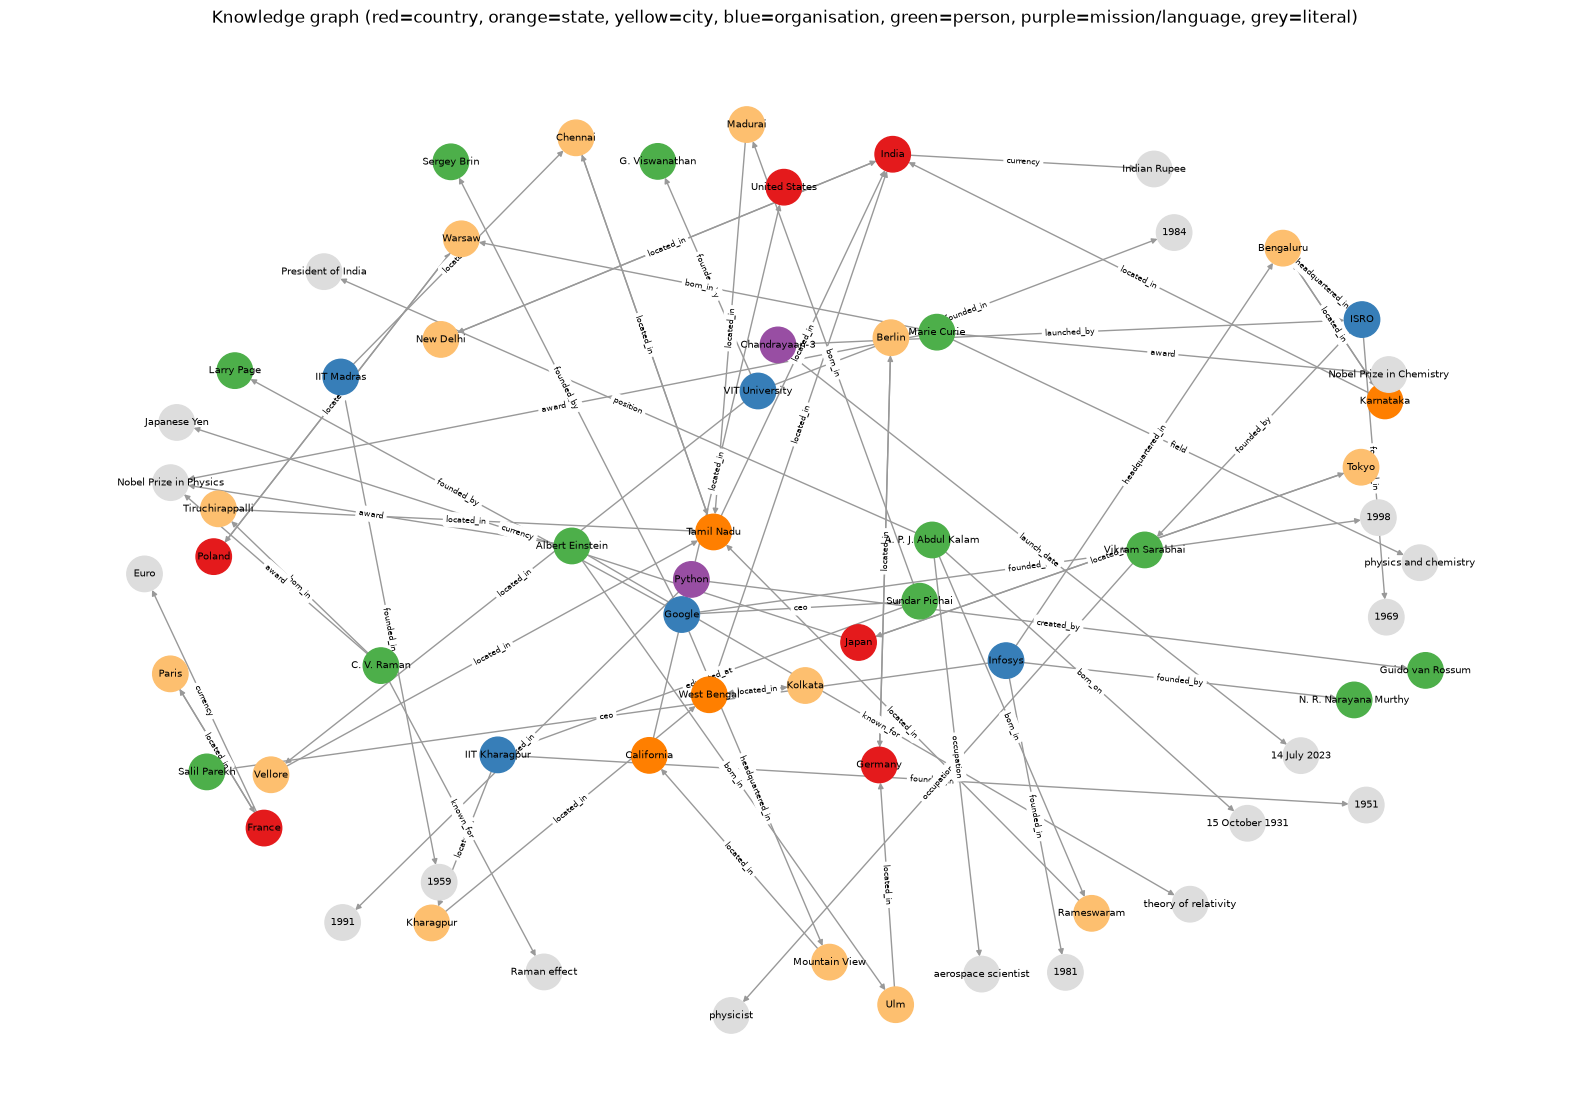

graph: 65 nodes, 70 edges


In [4]:
g = nx.DiGraph()
for s, r, o in TRIPLES:
    g.add_edge(s, o, label=r)
colors = {"country": "#e41a1c", "state": "#ff7f00", "city": "#fdbf6f", "organization": "#377eb8",
          "person": "#4daf4a", "mission": "#984ea3", "language": "#984ea3"}
fig = plt.figure(figsize=(20, 14))
pos = nx.spring_layout(g, k=0.9, seed=3)
nx.draw_networkx(g, pos, node_size=650, font_size=7, arrowsize=8, edge_color="#999999",
                 node_color=[colors.get(kb.type_of.get(n), "#dddddd") for n in g.nodes])
nx.draw_networkx_edge_labels(g, pos, edge_labels=nx.get_edge_attributes(g, "label"), font_size=6)
plt.title("Knowledge graph (red=country, orange=state, yellow=city, blue=organisation, "
          "green=person, purple=mission/language, grey=literal)")
plt.axis("off")
fig.savefig(OUT / "knowledge_graph_notebook.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"graph: {g.number_of_nodes()} nodes, {g.number_of_edges()} edges")

## 2. Knowledge-based QA (`kbqa.py`)

Pipeline: normalise the question, link entities (longest exact n-gram against names and aliases, then fuzzy `difflib`
matching for typos), detect relations with ordered regex patterns, read the expected answer type ("which state"),
run the structured query forward then inverse, climb `located_in` edges for multi-hop answers, and `COUNT` for
"how many". If any step fails the system abstains.

In [5]:
probe = ["Who is the CEO of Google?", "Who is the CEO of Gogle?", "Where was Abdul Kalam born?",
         "Where is Bangalore located?", "Chennai is the capital of which state?",
         "In which state is the headquarters of Infosys?", "What is the capital of Brazil?"]
rows = []
for q in probe:
    links = kb.link_entities(q)
    rows.append((q, "; ".join(f"{e} <- '{gram}' ({how})" for e, gram, how in links) or "-",
                 ", ".join(kb.detect_relations(q)) or "-", kb.expected_type(q) or "-"))
html_table(["question", "entity linking (entity <- surface form (method))", "relations detected (priority order)",
            "expected type"], rows, caption="Steps 2-4: entity linking, relation detection, expected answer type",
           highlight=lambda r: "#fff3cd" if "fuzzy" in r[1] else None)
print("Highlighted row: 'Gogle' is linked to Google by fuzzy matching.")

question,entity linking (entity <- surface form (method)),relations detected (priority order),expected type
Who is the CEO of Google?,Google <- 'google' (exact),"ceo, occupation",-
Who is the CEO of Gogle?,Google <- 'gogle' (fuzzy),"ceo, occupation",-
Where was Abdul Kalam born?,A. P. J. Abdul Kalam <- 'abdul kalam' (exact),"born_in, located_in",-
Where is Bangalore located?,Bengaluru <- 'bangalore' (exact),located_in,-
Chennai is the capital of which state?,Chennai <- 'chennai' (exact),capital,state
In which state is the headquarters of Infosys?,Infosys <- 'infosys' (exact),"headquartered_in, located_in",state
What is the capital of Brazil?,-,capital,-


Highlighted row: 'Gogle' is linked to Google by fuzzy matching.


In [6]:
cases = [("SIMPLE (forward query)", "Who is the CEO of Google?"),
         ("INVERSE (?x, rel, entity)", "Which company is led by Sundar Pichai?"),
         ("MULTI-HOP (climb located_in)", "In which country is VIT University located?"),
         ("COUNT aggregation", "How many Nobel Prizes did Marie Curie win?"),
         ("TYPO (fuzzy entity link)", "Who is the CEO of Gogle?")]
for label, q in cases:
    print(f"--- {label}")
    qs.show_kb_answer(kb, q)
    print()

--- SIMPLE (forward query)
Q: Who is the CEO of Google?
   entities : [('Google', 'exact')]
   relations: ['ceo', 'occupation'] | expected type: -
   query    : SELECT ?x WHERE { <Google> <ceo> ?x }
   evidence : (Google, ceo, Sundar Pichai)
   ANSWER   : Sundar Pichai

--- INVERSE (?x, rel, entity)
Q: Which company is led by Sundar Pichai?
   entities : [('Sundar Pichai', 'exact')]
   relations: ['ceo'] | expected type: organization
   query    : SELECT ?x WHERE { ?x <ceo> <Sundar Pichai> }
   evidence : (Google, ceo, Sundar Pichai)
   ANSWER   : Google

--- MULTI-HOP (climb located_in)
Q: In which country is VIT University located?
   entities : [('VIT University', 'exact')]
   relations: ['located_in'] | expected type: country
   query    : SELECT ?x WHERE { <VIT University> <located_in> ?x }
   evidence : (VIT University, located_in, Vellore) -> (Vellore, located_in, Tamil Nadu) -> (Tamil Nadu, located_in, India)
   ANSWER   : India

--- COUNT aggregation
Q: How many Nobel Prizes d

In [7]:
print("--- ABSTENTION: the system says 'I don't know' instead of guessing")
for q in ["Who is the CEO of ISRO?", "What is the capital of Brazil?", "Who founded Microsoft?",
          "When did Chandrayaan-3 land on the Moon?"]:
    qs.show_kb_answer(kb, q)
    print()

--- ABSTENTION: the system says 'I don't know' instead of guessing
Q: Who is the CEO of ISRO?
   entities : [('ISRO', 'exact')]
   relations: ['ceo', 'occupation'] | expected type: -
   ANSWER   : I don't know (no triple matches entity ['ISRO'] with relation(s) ['ceo', 'occupation'])

Q: What is the capital of Brazil?
   entities : -
   relations: ['capital'] | expected type: -
   ANSWER   : I don't know (no known entity found in the question)

Q: Who founded Microsoft?
   entities : -
   relations: ['founded_by'] | expected type: -
   ANSWER   : I don't know (no known entity found in the question)

Q: When did Chandrayaan-3 land on the Moon?
   entities : [('Chandrayaan-3', 'exact')]
   relations: - | expected type: -
   ANSWER   : I don't know (entity 'Chandrayaan-3' found, but no known relation matched the question)



## 3. Deep-learning QA (`neural_qa.py`)

A TF-IDF retriever picks the top passages; a SQuAD-fine-tuned Transformer reader gives a start and an end logit per
token and the answer is the span maximising `start[i] + end[j]`. DistilBERT (SQuAD 1.1) always returns a span;
RoBERTa (SQuAD 2.0) scores a "null" answer at the `[CLS]` position and abstains when that wins. Model loading is
wrapped in `try/except`, so a failure here cannot break the knowledge-base sections. RoBERTa tokens are shown with a leading `Ġ`, which marks a preceding space.

In [8]:
neural = {}        # name -> NeuralQA ; stays empty if RUN_NEURAL is False or loading fails
if RUN_NEURAL:
    try:
        from neural_qa import NeuralQA, TfidfRetriever, ExtractiveReader
    except Exception as e:
        print(f"NEURAL PART DISABLED - could not import neural_qa: {type(e).__name__}: {str(e)[:200]}")
    else:
        try:                                                    # keep the saved notebook free of progress-bar widgets
            from transformers.utils import logging as hf_logging
            hf_logging.disable_progress_bar()
        except Exception:
            pass
        for name, model in qs.READERS.items():
            t0 = time.time()
            try:
                neural[name] = NeuralQA(PASSAGES, model, 2)       # top-k = 2 passages, the script default
                print(f"Loaded {model} in {time.time() - t0:.1f}s "
                      f"({'can' if neural[name].reader.can_abstain else 'cannot'} abstain)")
            except Exception as e:
                print(f"Could not load {model}: {type(e).__name__}: {str(e)[:200]}")
    if not neural:
        print("No neural reader available: continuing with the knowledge-based system only.")
else:
    print("RUN_NEURAL = False: neural readers are not loaded.")
print("Neural systems available:", list(neural))

Loaded distilbert-base-cased-distilled-squad in 5.6s (cannot abstain)


Loaded deepset/roberta-base-squad2 in 1.8s (can abstain)
Neural systems available: ['DistilBERT (SQuAD 1.1)', 'RoBERTa (SQuAD 2.0)']


In [9]:
if neural:
    retr = next(iter(neural.values())).retriever
    for q in ["Where was Marie Curie born?", "When did Chandrayaan-3 land on the Moon?", "Who founded Microsoft?"]:
        hits = retr.retrieve(q, 3)
        html_table(["rank", "passage id", "tf-idf cosine", "passage start"],
                   [(k + 1, pid, f"{sim:.3f}", PASSAGES[pid][:90] + "...") for k, (pid, sim) in enumerate(hits)],
                   caption=f"TF-IDF retriever: {q}")
else:
    print("skipped (no neural reader)")

rank,passage id,tf-idf cosine,passage start
1,8,0.246,"Marie Curie was a physicist and chemist born in Warsaw, Poland. She won two Nobel Prizes: ..."
2,5,0.055,"Sundar Pichai was born in Madurai, Tamil Nadu, in 1972. He studied metallurgical engineeri..."
3,6,0.048,"A. P. J. Abdul Kalam was born on 15 October 1931 in Rameswaram, Tamil Nadu. He was an aero..."


rank,passage id,tf-idf cosine,passage start
1,7,0.244,"The Indian Space Research Organisation (ISRO) is India's national space agency, headquarte..."
2,0,0.000,"India is a country in South Asia. Its capital is New Delhi, and its currency is the Indian..."
3,2,0.000,Vellore Institute of Technology (VIT University) is a private university located in Vellor...


rank,passage id,tf-idf cosine,passage start
1,3,0.110,Infosys is an Indian multinational information technology company headquartered in Bengalu...
2,4,0.106,Google was founded in 1998 by Larry Page and Sergey Brin while they were PhD students at S...
3,2,0.083,Vellore Institute of Technology (VIT University) is a private university located in Vellor...


In [10]:
import numpy as np, torch

def trace_spans(reader, question, context, top_n=20, max_answer_len=30, show=5):
    # The same computation as ExtractiveReader.read, with every intermediate value printed.
    enc = reader.tok(question, context, truncation="only_second", max_length=reader.max_length,
                     stride=reader.stride, return_overflowing_tokens=True, return_offsets_mapping=True,
                     padding=True, return_tensors="pt")
    offsets = enc.pop("offset_mapping")
    enc.pop("overflow_to_sample_mapping", None)
    with torch.no_grad():
        out = reader.model(**{k: v for k, v in enc.items() if k in ("input_ids", "attention_mask", "token_type_ids")})
    best = {"text": "", "score": -1e9}
    null_score = -1e9
    print(f"model: {reader.name} | {out.start_logits.shape[0]} window(s) x {out.start_logits.shape[1]} tokens")
    for w in range(out.start_logits.shape[0]):
        s, e = out.start_logits[w].numpy(), out.end_logits[w].numpy()
        toks = reader.tok.convert_ids_to_tokens(enc["input_ids"][w])
        ctx = [i for i, sid in enumerate(enc.sequence_ids(w)) if sid == 1]
        null_score = max(null_score, float(s[0] + e[0]))
        print(f"window {w}: {len(ctx)} passage tokens | null score (start[CLS]+end[CLS]) = {s[0] + e[0]:.2f}")
        starts = [i for i in np.argsort(-s)[:top_n] if i in ctx]
        ends = [j for j in np.argsort(-e)[:top_n] if j in ctx]
        html_table(["rank", "token idx", "token", "start logit"],
                   [(k + 1, i, toks[i], f"{s[i]:.2f}") for k, i in enumerate(starts[:show])],
                   caption=f"top {show} START candidates")
        html_table(["rank", "token idx", "token", "end logit"],
                   [(k + 1, j, toks[j], f"{e[j]:.2f}") for k, j in enumerate(ends[:show])],
                   caption=f"top {show} END candidates")
        spans = []
        for i in starts:
            for j in ends:
                if j < i or j - i + 1 > max_answer_len:
                    continue
                a, b = int(offsets[w][i][0]), int(offsets[w][j][1])
                spans.append((float(s[i] + e[j]), i, j, context[a:b]))
        spans.sort(reverse=True)
        html_table(["rank", "start", "end", "score = start[i]+end[j]", "span text"],
                   [(k + 1, i, j, f"{sc:.2f}", t) for k, (sc, i, j, t) in enumerate(spans[:show])],
                   caption=f"top {show} valid spans (i <= j, length <= {max_answer_len})")
        if spans and spans[0][0] > best["score"]:
            best = {"text": spans[0][3], "score": spans[0][0]}
    decision = ("ABSTAIN (null score beats best span)" if reader.can_abstain and null_score > best["score"]
                else "answer with the span")
    print(f"CHOSEN SPAN: {best['text']!r} (score {best['score']:.2f}) | null score {null_score:.2f} "
          f"| model can abstain: {reader.can_abstain} -> {decision}")
    ref = reader.read(question, context)
    print(f"check against ExtractiveReader.read(): {ref['text']!r} (score {ref['score']:.2f}) "
          f"-> {'identical' if ref['text'] == best['text'] else 'DIFFERENT'}")
    return best

In [11]:
Q_TRACE = "Where was Marie Curie born?"
if neural:
    for name, qa in neural.items():
        pid, sim = qa.retriever.retrieve(Q_TRACE, 1)[0]
        print("=" * 90)
        print(f"{name} | Q: {Q_TRACE} | top passage #{pid} (tf-idf {sim:.2f})")
        print("=" * 90)
        trace_spans(qa.reader, Q_TRACE, PASSAGES[pid])
        print()
else:
    print("skipped (no neural reader)")

DistilBERT (SQuAD 1.1) | Q: Where was Marie Curie born? | top passage #8 (tf-idf 0.25)
model: distilbert-base-cased-distilled-squad | 1 window(s) x 101 tokens
window 0: 90 passage tokens | null score (start[CLS]+end[CLS]) = -1.20


rank,token idx,token,start logit
1,21,Warsaw,11.67
2,23,Poland,6.18
3,20,in,4.80
4,19,born,3.72
5,10,Marie,3.34


rank,token idx,token,end logit
1,23,Poland,12.27
2,21,Warsaw,8.10
3,24,.,7.48
4,62,##li,3.42
5,22,",",2.76


rank,start,end,score = start[i]+end[j],span text
1,21,23,23.94,"Warsaw, Poland"
2,21,21,19.77,Warsaw
3,21,24,19.15,"Warsaw, Poland."
4,23,23,18.45,Poland
5,20,23,17.07,"in Warsaw, Poland"


CHOSEN SPAN: 'Warsaw, Poland' (score 23.94) | null score -1.20 | model can abstain: False -> answer with the span
check against ExtractiveReader.read(): 'Warsaw, Poland' (score 23.94) -> identical

RoBERTa (SQuAD 2.0) | Q: Where was Marie Curie born? | top passage #8 (tf-idf 0.25)


model: deepset/roberta-base-squad2 | 1 window(s) x 99 tokens
window 0: 88 passage tokens | null score (start[CLS]+end[CLS]) = 4.70


rank,token idx,token,start logit
1,20,ĠWarsaw,7.30
2,22,ĠPoland,1.60
3,10,Marie,0.05
4,19,Ġin,0.04
5,18,Ġborn,-0.27


rank,token idx,token,end logit
1,22,ĠPoland,7.60
2,20,ĠWarsaw,3.98
3,78,.,1.22
4,23,.,1.22
5,97,.,1.22


rank,start,end,score = start[i]+end[j],span text
1,20,22,14.90,"Warsaw, Poland"
2,20,20,11.28,Warsaw
3,22,22,9.20,Poland
4,20,23,8.52,"Warsaw, Poland."
5,20,46,8.52,"Warsaw, Poland. She won two Nobel Prizes: the Nobel Prize in Physics in 1903 and the Nobel Prize in Chemistry in 1911."


CHOSEN SPAN: 'Warsaw, Poland' (score 14.90) | null score 4.70 | model can abstain: True -> answer with the span
check against ExtractiveReader.read(): 'Warsaw, Poland' (score 14.90) -> identical



In [12]:
# An unanswerable question: SQuAD-1.1 DistilBERT still returns a span, SQuAD-2.0 RoBERTa may prefer the null answer.
Q_NO = "Who founded Microsoft?"
if neural:
    for name, qa in neural.items():
        pid, sim = qa.retriever.retrieve(Q_NO, 1)[0]
        print("=" * 90)
        print(f"{name} | Q: {Q_NO} | top passage #{pid} (tf-idf {sim:.2f})")
        print("=" * 90)
        trace_spans(qa.reader, Q_NO, PASSAGES[pid], show=3)
        print()
        qs.show_neural_answer(name, qa, Q_NO)       # full NeuralQA answer (top-2 passages)
        print()
else:
    print("skipped (no neural reader)")

DistilBERT (SQuAD 1.1) | Q: Who founded Microsoft? | top passage #3 (tf-idf 0.11)


model: distilbert-base-cased-distilled-squad | 1 window(s) x 62 tokens
window 0: 55 passage tokens | null score (start[CLS]+end[CLS]) = -1.81


rank,token idx,token,start logit
1,28,N,10.91
2,32,Narayan,6.55
3,30,R,3.56


rank,token idx,token,end logit
1,36,##y,11.49
2,40,engineers,6.91
3,41,.,5.53


rank,start,end,score = start[i]+end[j],span text
1,28,36,22.40,N. R. Narayana Murthy
2,32,36,18.04,Narayana Murthy
3,28,40,17.81,N. R. Narayana Murthy and six other engineers


...

rank,token idx,token,start logit
1,28,ĠN,-5.28
2,42,ĠSal,-7.13
3,7,Inf,-7.49


rank,token idx,token,end logit
1,36,thy,-5.37
2,59,.,-5.51
3,21,.,-5.51


rank,start,end,score = start[i]+end[j],span text
1,28,36,-10.65,N. R. Narayana Murthy
2,28,41,-10.79,N. R. Narayana Murthy and six other engineers.
3,28,46,-11.68,N. R. Narayana Murthy and six other engineers. Salil Parekh


CHOSEN SPAN: 'N. R. Narayana Murthy' (score -10.65) | null score 9.13 | model can abstain: True -> ABSTAIN (null score beats best span)


check against ExtractiveReader.read(): 'N. R. Narayana Murthy' (score -10.65) -> identical

   [RoBERTa (SQuAD 2.0)] top passage #3 (tf-idf 0.11) | span score -10.65 | null score 9.13 | confidence 0.00
   [RoBERTa (SQuAD 2.0)] ANSWER: no answer (abstained)



## 4. Hybrid system

As defined in `qa_system.py`: ask the knowledge base first; only when it abstains fall back to the RoBERTa reader
(which may itself abstain). The table shows who answered each question.

In [13]:
rob = neural.get("RoBERTa (SQuAD 2.0)")

def hybrid(q):
    # Same logic as the closure in qa_system.main()
    a = kb.answer(q).answer
    return (a, {"source": "KB"}) if a is not None else (rob.answer(q)["answer"], {"source": "DL"})

if rob is not None:
    demo = ["Who is the CEO of Google?", "In which country is VIT University located?",
            "How many Nobel Prizes did Marie Curie win?", "When did Chandrayaan-3 land on the Moon?",
            "By what nickname is Abdul Kalam popularly known?", "When was Python released?",
            "What is the capital of Brazil?", "Who founded Microsoft?"]
    rows = []
    for q in demo:
        kba = kb.answer(q).answer
        dist = neural["DistilBERT (SQuAD 1.1)"].answer(q)["answer"] if "DistilBERT (SQuAD 1.1)" in neural else "-"
        roba = rob.answer(q)["answer"]
        ans, info = hybrid(q)
        rows.append((q, kba if kba is not None else "<abstain>", dist if dist is not None else "<abstain>",
                     roba if roba is not None else "<abstain>",
                     ans if ans is not None else "<abstain>", info["source"]))
    html_table(["question", "KB", "DistilBERT", "RoBERTa", "HYBRID", "hybrid source"], rows,
               caption="Hybrid (KB -> RoBERTa fallback) on example questions",
               highlight=lambda r: "#e2f0d9" if r[5] == "KB" else "#deebf7")
    print("green = answered by the KB, blue = KB abstained and RoBERTa was used")
else:
    print("RoBERTa reader not available: the hybrid system is not built (as in qa_system.py).")

question,KB,DistilBERT,RoBERTa,HYBRID,hybrid source
Who is the CEO of Google?,Sundar Pichai,Salil Parekh,Sundar Pichai,Sundar Pichai,KB
In which country is VIT University located?,India,California,Tamil Nadu,India,KB
How many Nobel Prizes did Marie Curie win?,2,two,two,2,KB
When did Chandrayaan-3 land on the Moon?,<abstain>,23 August 2023,23 August 2023,23 August 2023,DL
By what nickname is Abdul Kalam popularly known?,<abstain>,Missile Man of India,Missile Man of India,Missile Man of India,DL
When was Python released?,1991,Python,<abstain>,1991,KB
What is the capital of Brazil?,<abstain>,New Delhi,<abstain>,<abstain>,DL
Who founded Microsoft?,<abstain>,N. R. Narayana Murthy,<abstain>,<abstain>,DL


green = answered by the KB, blue = KB abstained and RoBERTa was used


## 5. Full evaluation

The 34 test questions (9 categories, 3 unanswerable) are run through every system with the script's own metric
functions (`exact_match`, `f1_score`, `summarise`) and the default settings (top-k = 2 passages). Per-question marks:
`+` exact match, `~` partial overlap, `x` wrong. Latency includes model warm-up on the first questions.

In [14]:
systems = {"Knowledge-based QA": lambda q: (kb.answer(q).answer, {})}
for name, qa in neural.items():
    systems[f"DL: {name}"] = (lambda qa_: (lambda q: (qa_.answer(q)["answer"], {})))(qa)
if rob is not None:
    systems["Hybrid (KB -> RoBERTa fallback)"] = hybrid

print(f"EVALUATION on {len(TEST_QUESTIONS)} questions "
      f"({sum(1 for _, g, _ in TEST_QUESTIONS if not g)} unanswerable), systems: {list(systems)}")
t_start = time.time()
results = {}
for sname, fn in systems.items():
    rows = []
    for q, gold, cat in TEST_QUESTIONS:
        t0 = time.time()
        pred, _ = fn(q)
        rows.append({"q": q, "gold": gold, "cat": cat, "pred": pred, "latency": time.time() - t0,
                     "em": qs.exact_match(pred, gold), "f1": qs.f1_score(pred, gold)})
    results[sname] = rows
    print(f"  {sname}: done")
print(f"evaluation time: {time.time() - t_start:.1f}s")

names = list(results)
short = {n: n.replace("DL: ", "").replace(" (KB -> RoBERTa fallback)", "")[:20] for n in names}

EVALUATION on 34 questions (3 unanswerable), systems: ['Knowledge-based QA', 'DL: DistilBERT (SQuAD 1.1)', 'DL: RoBERTa (SQuAD 2.0)', 'Hybrid (KB -> RoBERTa fallback)']
  Knowledge-based QA: done


  DL: DistilBERT (SQuAD 1.1): done


  DL: RoBERTa (SQuAD 2.0): done


  Hybrid (KB -> RoBERTa fallback): done
evaluation time: 19.4s


In [15]:
rows = []
for i, (q, gold, cat) in enumerate(TEST_QUESTIONS):
    row = [i + 1, cat, q, gold[0] if gold else "<none>"]
    for n in names:
        r = results[n][i]
        mark = "+" if r["em"] else ("~" if r["f1"] > 0 else "x")
        row.append(f"{mark} {r['pred'] if r['pred'] is not None else '<no answer>'}")
    rows.append(row)
html_table(["#", "category", "question", "gold"] + [short[n] for n in names], rows,
           caption="Per-question predictions (+ exact match, ~ partial overlap, x wrong)")

#,category,question,gold,Knowledge-based QA,DistilBERT (SQuAD 1.,RoBERTa (SQuAD 2.0),Hybrid
1,simple,What is the capital of India?,New Delhi,+ New Delhi,x Tokyo,+ New Delhi,+ New Delhi
2,simple,Who founded Infosys?,N. R. Narayana Murthy,+ N. R. Narayana Murthy,+ N. R. Narayana Murthy,+ N. R. Narayana Murthy,+ N. R. Narayana Murthy
3,simple,When was IIT Madras founded?,1959,+ 1959,+ 1959,+ 1959,+ 1959
4,simple,Where was Sundar Pichai born?,Madurai,+ Madurai,"~ Madurai, Tamil Nadu","~ Madurai, Tamil Nadu",+ Madurai
5,simple,Who is the CEO of Google?,Sundar Pichai,+ Sundar Pichai,x Salil Parekh,+ Sundar Pichai,+ Sundar Pichai
6,simple,What is the currency of Japan?,Japanese Yen,+ Japanese Yen,+ Japanese Yen,+ Japanese Yen,+ Japanese Yen
7,simple,What is C. V. Raman known for?,Raman effect,+ Raman effect,~ Missile Man of India,x <no answer>,+ Raman effect
8,simple,Who launched Chandrayaan-3?,ISRO,+ ISRO,+ ISRO,+ Indian Space Research Organisation,+ ISRO
9,simple,Where is ISRO headquartered?,Bengaluru,+ Bengaluru,+ Bengaluru,+ Bengaluru,+ Bengaluru
10,simple,When was A. P. J. Abdul Kalam born?,15 October 1931,+ 15 October 1931,+ 15 October 1931,+ 15 October 1931,+ 15 October 1931


In [16]:
summ = {n: qs.summarise(results[n]) for n in names}
metrics = list(next(iter(summ.values())))
rows = [[m] + [(f"{summ[n][m]:.1f}" if "Latency" in m else f"{summ[n][m]:.3f}") for n in names] for m in metrics]
html_table(["Metric"] + [short[n] for n in names], rows, caption="Summary metrics")

Metric,Knowledge-based QA,DistilBERT (SQuAD 1.,RoBERTa (SQuAD 2.0),Hybrid
EM,0.912,0.559,0.765,1.000
F1,0.912,0.615,0.814,1.000
EM (answerable),0.903,0.613,0.742,1.000
Coverage,0.903,1.000,0.903,1.000
Precision@answered,1.000,0.613,0.821,1.000
Abstention acc.,1.000,0.000,1.000,1.000
Latency (ms),1.5,170.1,330.2,66.8


In [17]:
cats = list(dict.fromkeys(c for _, _, c in TEST_QUESTIONS))
rows = []
for c in cats:
    idx = [i for i, (_, _, cc) in enumerate(TEST_QUESTIONS) if cc == c]
    rows.append([c, len(idx)] + [f"{sum(results[n][i]['em'] for i in idx) / len(idx):.2f}" for n in names])
html_table(["Category", "#"] + [short[n] for n in names], rows, caption="Exact Match per question category")

with open(OUT / "qa_results_notebook.json", "w", encoding="utf-8") as f:
    json.dump({"summary": summ, "per_question": results}, f, indent=1)
print("Saved:", OUT / "qa_results_notebook.json")

Category,#,Knowledge-based QA,DistilBERT (SQuAD 1.,RoBERTa (SQuAD 2.0),Hybrid
simple,10,1.00,0.60,0.80,1.00
paraphrase,6,1.00,0.83,0.83,1.00
inverse,3,1.00,0.67,1.00,1.00
multi-hop,4,1.00,0.50,0.50,1.00
typo/alias,3,1.00,0.00,0.33,1.00
aggregation,1,1.00,1.00,1.00,1.00
text-only,3,0.00,1.00,1.00,1.00
kb-only,1,1.00,0.00,0.00,1.00
unanswerable,3,1.00,0.00,1.00,1.00


Saved: U:\VITc\speech lab\notebooks\lab6_outputs\qa_results_notebook.json


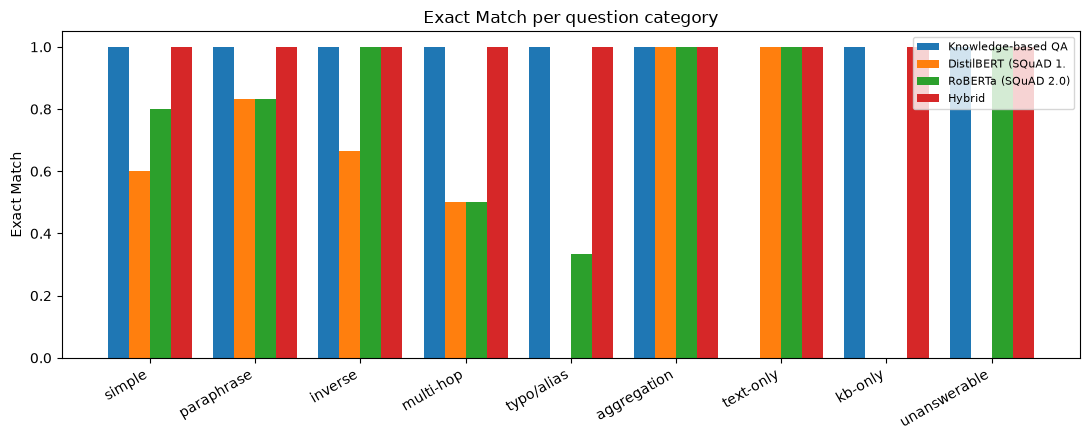

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4.5))
w = 0.8 / len(names)
for k, n in enumerate(names):
    vals = [sum(results[n][i]["em"] for i, (_, _, cc) in enumerate(TEST_QUESTIONS) if cc == c) /
            sum(1 for _, _, cc in TEST_QUESTIONS if cc == c) for c in cats]
    ax.bar([x + k * w for x in range(len(cats))], vals, w, label=short[n])
ax.set_xticks([x + 0.4 - w / 2 for x in range(len(cats))])
ax.set_xticklabels(cats, rotation=30, ha="right")
ax.set_ylabel("Exact Match"); ax.set_ylim(0, 1.05); ax.legend(fontsize=8)
ax.set_title("Exact Match per question category")
plt.tight_layout()
fig.savefig(OUT / "em_per_category.png", dpi=100)
plt.show()

## 6. The `--ask` demo

`python qa_system.py --ask "..."` shows the knowledge-based answer (with entities, relations, query and evidence), the
answer of each neural reader and the hybrid answer. `ask()` below repeats that loop body from `main()`.

In [19]:
def ask(q):
    qs.banner(f"YOUR QUESTION: {q}")
    kr = qs.show_kb_answer(kb, q)
    for name, qa in neural.items():
        qs.show_neural_answer(name, qa, q)
    if neural:
        fallback = "RoBERTa (SQuAD 2.0)" if "RoBERTa (SQuAD 2.0)" in neural else next(iter(neural))
        final = kr.answer if kr.answer is not None else neural[fallback].answer(q)["answer"]
        print(f"   HYBRID ANSWER: {final if final is not None else 'I do not know'}")

for q in ["Where was Sundar Pichai born?", "Who runs Google?"]:
    ask(q)


YOUR QUESTION: Where was Sundar Pichai born?
Q: Where was Sundar Pichai born?
   entities : [('Sundar Pichai', 'exact')]
   relations: ['born_in', 'located_in'] | expected type: -
   query    : SELECT ?x WHERE { <Sundar Pichai> <born_in> ?x }
   evidence : (Sundar Pichai, born_in, Madurai)
   ANSWER   : Madurai


   [DistilBERT (SQuAD 1.1)] top passage #5 (tf-idf 0.36) | span score 21.90 | null score -2.76 | confidence 0.59
   [DistilBERT (SQuAD 1.1)] ANSWER: Madurai, Tamil Nadu


   [RoBERTa (SQuAD 2.0)] top passage #5 (tf-idf 0.36) | span score 13.81 | null score 1.68 | confidence 0.53
   [RoBERTa (SQuAD 2.0)] ANSWER: Madurai, Tamil Nadu
   HYBRID ANSWER: Madurai

YOUR QUESTION: Who runs Google?
Q: Who runs Google?
   entities : [('Google', 'exact')]
   relations: - | expected type: -
   ANSWER   : I don't know (entity 'Google' found, but no known relation matched the question)


   [DistilBERT (SQuAD 1.1)] top passage #4 (tf-idf 0.27) | span score 20.67 | null score -5.21 | confidence 0.98
   [DistilBERT (SQuAD 1.1)] ANSWER: Larry Page and Sergey Brin
   [RoBERTa (SQuAD 2.0)] top passage #4 (tf-idf 0.27) | span score 10.31 | null score 3.12 | confidence 0.66
   [RoBERTa (SQuAD 2.0)] ANSWER: Sundar Pichai


   HYBRID ANSWER: Sundar Pichai


## 7. Interactive mode

`--interactive` reads questions with `input()` and needs a terminal, so it is not called here. Instead the same
`ask()` function is applied to a list of example questions, including new phrasings the hand-written patterns were not
designed for.

In [20]:
EXAMPLES = ["What is the currency of France?", "Which country is Chennai in?", "Who is the founder of Infosys?",
            "What's the HQ city of Infosys?", "When was Infosys started?", "Who invented Python?",
            "Who is the prime minister of India?"]
for q in EXAMPLES:
    ask(q)


YOUR QUESTION: What is the currency of France?
Q: What is the currency of France?
   entities : [('France', 'exact')]
   relations: ['currency'] | expected type: -
   query    : SELECT ?x WHERE { <France> <currency> ?x }
   evidence : (France, currency, Euro)
   ANSWER   : Euro


   [DistilBERT (SQuAD 1.1)] top passage #1 (tf-idf 0.21) | span score 22.10 | null score -1.88 | confidence 0.92
   [DistilBERT (SQuAD 1.1)] ANSWER: Indian Rupee


   [RoBERTa (SQuAD 2.0)] top passage #1 (tf-idf 0.21) | span score 7.45 | null score 6.80 | confidence 0.27
   [RoBERTa (SQuAD 2.0)] ANSWER: Euro
   HYBRID ANSWER: Euro

YOUR QUESTION: Which country is Chennai in?
Q: Which country is Chennai in?
   entities : [('Chennai', 'exact')]
   relations: - | expected type: country
   ANSWER   : I don't know (entity 'Chennai' found, but no known relation matched the question)
   [DistilBERT (SQuAD 1.1)] top passage #0 (tf-idf 0.15) | span score 17.78 | null score -6.11 | confidence 1.00
   [DistilBERT (SQuAD 1.1)] ANSWER: India


   [RoBERTa (SQuAD 2.0)] top passage #0 (tf-idf 0.15) | span score 4.40 | null score 6.25 | confidence 0.08
   [RoBERTa (SQuAD 2.0)] ANSWER: India


   HYBRID ANSWER: India

YOUR QUESTION: Who is the founder of Infosys?
Q: Who is the founder of Infosys?
   entities : [('Infosys', 'exact')]
   relations: ['founded_by', 'occupation'] | expected type: -
   query    : SELECT ?x WHERE { <Infosys> <founded_by> ?x }
   evidence : (Infosys, founded_by, N. R. Narayana Murthy)
   ANSWER   : N. R. Narayana Murthy


...

   [DistilBERT (SQuAD 1.1)] top passage #3 (tf-idf 0.28) | span score 22.81 | null score -1.43 | confidence 0.99
   [DistilBERT (SQuAD 1.1)] ANSWER: 1981


   [RoBERTa (SQuAD 2.0)] top passage #3 (tf-idf 0.28) | span score 15.04 | null score 2.11 | confidence 0.99
   [RoBERTa (SQuAD 2.0)] ANSWER: 1981
   HYBRID ANSWER: 1981

YOUR QUESTION: Who invented Python?
Q: Who invented Python?
   entities : [('Python', 'exact')]
   relations: ['created_by'] | expected type: -
   query    : SELECT ?x WHERE { <Python> <created_by> ?x }
   evidence : (Python, created_by, Guido van Rossum)
   ANSWER   : Guido van Rossum
   [DistilBERT (SQuAD 1.1)] top passage #9 (tf-idf 0.17) | span score 20.69 | null score -4.63 | confidence 0.97
   [DistilBERT (SQuAD 1.1)] ANSWER: Guido van Rossum


   [RoBERTa (SQuAD 2.0)] top passage #9 (tf-idf 0.17) | span score 16.17 | null score 3.95 | confidence 0.98
   [RoBERTa (SQuAD 2.0)] ANSWER: Guido van Rossum
   HYBRID ANSWER: Guido van Rossum

YOUR QUESTION: Who is the prime minister of India?
Q: Who is the prime minister of India?
   entities : [('India', 'exact')]
   relations: ['occupation'] | expected type: -
   ANSWER   : I don't know (no triple matches entity ['India'] with relation(s) ['occupation'])
   [DistilBERT (SQuAD 1.1)] top passage #0 (tf-idf 0.19) | span score 13.90 | null score -8.38 | confidence 0.82
   [DistilBERT (SQuAD 1.1)] ANSWER: A. P. J. Abdul Kalam


   [RoBERTa (SQuAD 2.0)] top passage #0 (tf-idf 0.19) | span score 1.86 | null score 7.64 | confidence 0.00
   [RoBERTa (SQuAD 2.0)] ANSWER: no answer (abstained)


   HYBRID ANSWER: I do not know


## 8. Notes / what to look for

All numbers below are the ones printed by the cells above (default settings, top-k = 2 passages).

**Knowledge base and KBQA**
- The KB has 70 triples, 65 entities/literals and 19 relations; the graph shows 65 nodes and 70 edges.
- The typo question "Who is the CEO of Gogle?" is answered because `gogle` is fuzzy-linked to Google, and the evidence path starts with the `[fuzzy entity link -> Google]` marker.
- The multi-hop question about VIT University returns India through three triples: VIT University -> Vellore -> Tamil Nadu -> India. The COUNT question about Marie Curie returns 2.
- Abstention has two distinct reasons: no entity found (Brazil, Microsoft) and entity found but no matching triple or relation (CEO of ISRO, Chandrayaan-3 landing).

**Readers**
- With span selection written out, the chosen span for "Where was Marie Curie born?" is `Warsaw, Poland` for both readers, identical to `ExtractiveReader.read()`. Neither model returns just `Warsaw`, so exact match gives credit only to the KB and hybrid answers.
- For "Who founded Microsoft?" DistilBERT (SQuAD 1.1) still returns a span (`N. R. Narayana Murthy`, score 22.40, null score -1.81). RoBERTa (SQuAD 2.0) finds the same best span (score -10.65) but its null score is 9.13, so it abstains.

**Evaluation (34 questions, 3 unanswerable)**

| System | EM | F1 | Coverage | Precision@answered | Abstention acc. |
|---|---|---|---|---|---|
| Knowledge-based | 0.912 | 0.912 | 0.903 | 1.000 | 1.000 |
| DistilBERT | 0.559 | 0.615 | 1.000 | 0.613 | 0.000 |
| RoBERTa | 0.765 | 0.814 | 0.903 | 0.821 | 1.000 |
| Hybrid | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 |

- The KB is exact on everything it answers (precision 1.000) but scores 0.00 EM on the 3 text-only questions, because no relation pattern or triple covers them. The neural readers get 1.00 EM there, while only the KB answers the kb-only Python question (1.00 vs 0.00 for both readers).
- The KB is perfect on multi-hop, typo/alias and aggregation questions. DistilBERT and RoBERTa reach 0.50 EM on multi-hop questions because the answer must be joined across passages (for example `California` and `Tamil Nadu` for the VIT University question).
- DistilBERT has abstention accuracy 0.000 and wrong answers on all 3 unanswerable questions, while RoBERTa abstains on all 3. RoBERTa's lower coverage (0.903) is the price: it also abstains on some answerable questions (C. V. Raman, Gogle, Python).
- Several neural "errors" are partial matches (`~`), for example `Madurai, Tamil Nadu` against gold `Madurai`: F1 is higher than EM for both readers.
- The hybrid reaches EM 1.000 and F1 1.000 because the KB covers the questions with structure and the reader covers the 3 text-only ones. The KB is faster than either neural reader by a wide margin in the Latency row, and the hybrid sits in between because it calls RoBERTa only on KB abstentions.

**Caveats**
- The relation patterns were written together with these test questions, so the 0.912 KB EM and the hybrid 1.000 are optimistic. In the `--ask` and example-question runs, "Who runs Google?", "Which country is Chennai in?" and "What's the HQ city of Infosys?" all make the KB abstain, and the hybrid has to rely on RoBERTa.
- DistilBERT answers confidently and wrongly in some cases (`Indian Rupee` for the currency of France, `Vikram Sarabhai` for the founder of Infosys), while RoBERTa answered both of those questions correctly (Euro, N. R. Narayana Murthy).
- RoBERTa is not always right: it answered `Tamil Nadu` for the VIT University country question, and the hybrid is only as good as the KB when the KB answers.